In [ ]:
# Adding in our imports prior to beginning the project
import shap
import numpy as np
import pandas as pd
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [ ]:
df = pd.read_csv('data.csv')   # dùng đường dẫn tuyệt đối
df.head(6)

,ticker,Name,environment_score,social_score,governance_score,total_score,Total ESG Risk score,Environment Risk Score,Governance Risk Score,Social Risk Score,...,Date,adj_close_lag_1,adj_close_lag_7,adj_close_lag_30,ma_7,ma_30,volatility_7,volatility_30,composite_esg_score,composite_esg_risk_score
0,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-14 00:00:00+00:00,108.017479,110.428772,106.811852,108.293337,108.769948,0.892777,1.251017,382.333333,5.233333
1,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-15 00:00:00+00:00,108.468369,109.203529,104.224129,108.458567,108.974481,1.157181,0.946782,382.333333,5.233333
2,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-19 00:00:00+00:00,110.360138,108.752617,107.439171,108.817039,109.101906,1.576243,0.989315,382.333333,5.233333
3,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-20 00:00:00+00:00,111.261925,109.301544,108.370354,109.120899,109.203846,1.863966,1.065930,382.333333,5.233333
4,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-21 00:00:00+00:00,111.428558,107.272537,109.213318,109.800034,109.297619,1.942662,1.183993,382.333333,5.233333
5,DIS,The Walt Disney Company,510,316,321,1147,15.7,0.0,6.7,9.0,...,2019-02-22 00:00:00+00:00,112.026482,107.037285,110.438568,110.647203,109.381915,1.826637,1.346851,382.333333,5.233333


In [ ]:
df.shape

(296334, 24)

In [ ]:
print(df.isnull().sum())

ticker                      0
Name                        0
environment_score           0
social_score                0
governance_score            0
total_score                 0
Total ESG Risk score        0
Environment Risk Score      0
Governance Risk Score       0
Social Risk Score           0
adj_close                   0
market_cap                  0
pe_ratio                    0
dividend_yield              0
Date                        0
adj_close_lag_1             0
adj_close_lag_7             0
adj_close_lag_30            0
ma_7                        0
ma_30                       0
volatility_7                0
volatility_30               0
composite_esg_score         0
composite_esg_risk_score    0
dtype: int64


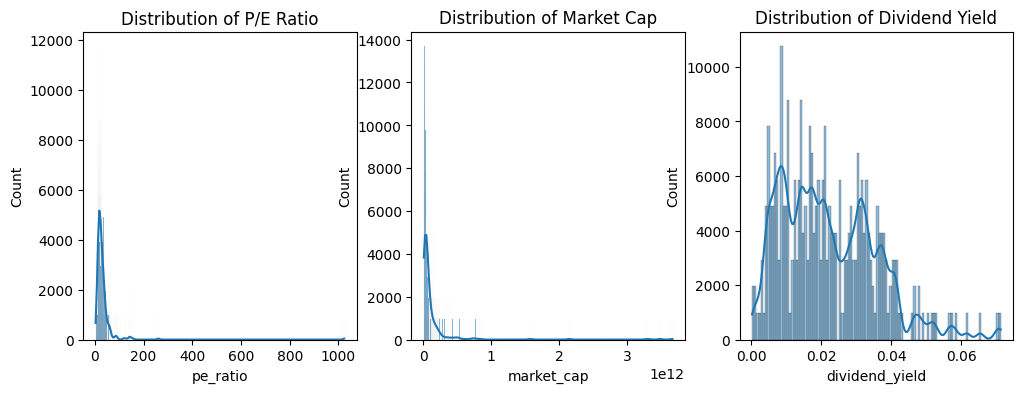

In [ ]:
# Check the distribution of financial metrics
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['pe_ratio'], kde=True)
plt.title('Distribution of P/E Ratio')

plt.subplot(1, 3, 2)
sns.histplot(df['market_cap'], kde=True)
plt.title('Distribution of Market Cap')

plt.subplot(1, 3, 3)
sns.histplot(df['dividend_yield'], kde=True)
plt.title('Distribution of Dividend Yield')
plt.show()

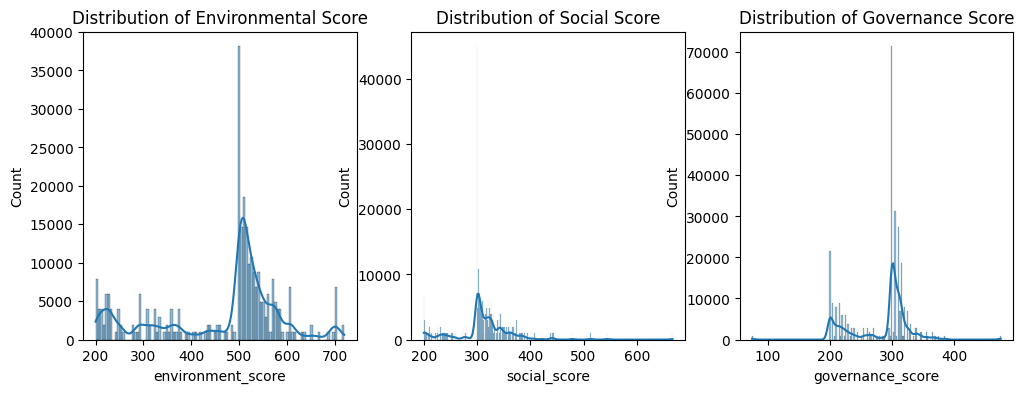

In [ ]:
# Check the distribution of ESG scores
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['environment_score'], kde=True)
plt.title('Distribution of Environmental Score')

plt.subplot(1, 3, 2)
sns.histplot(df['social_score'], kde=True)
plt.title('Distribution of Social Score')

plt.subplot(1, 3, 3)
sns.histplot(df['governance_score'], kde=True)
plt.title('Distribution of Governance Score')
plt.show()

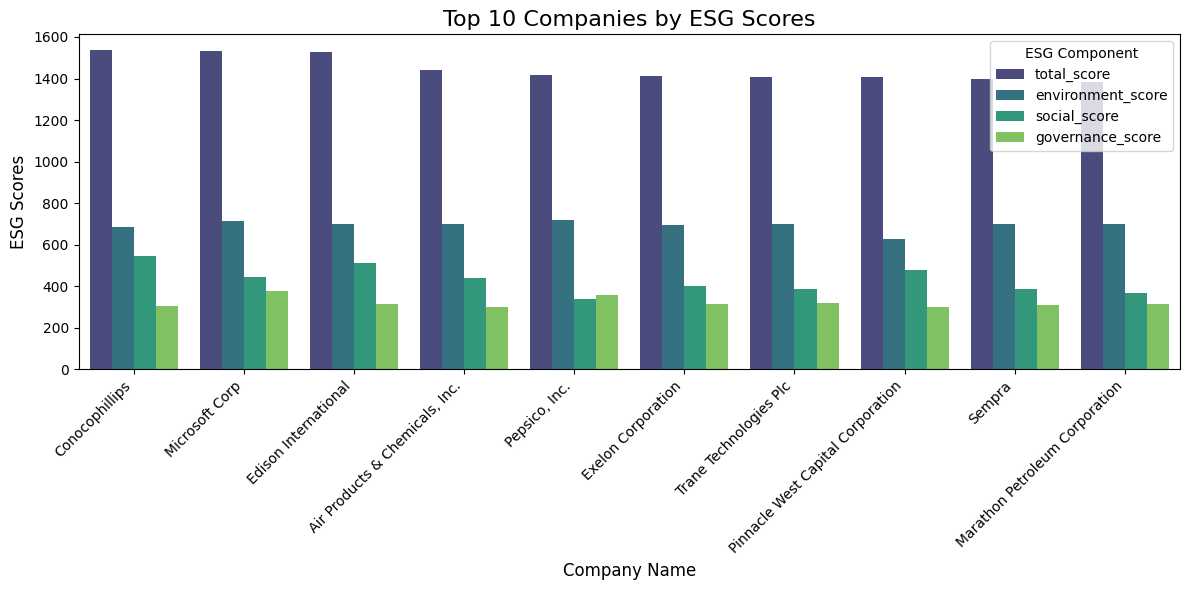

In [ ]:
#Tính điểm esg trung trình (e_score, social_score, govermace_score, total score)
agg_data = df.groupby("Name").agg({
    "environment_score": "mean",
    "social_score": "mean",
    "governance_score": "mean",
    "total_score": "mean"
}).reset_index()

# Sorting data by total_score and extracting the top 10 companies
top_10_companies = agg_data.sort_values(by="total_score", ascending=False).head(10)

top_10_companies_melted = top_10_companies.melt(
    id_vars="Name",
    value_vars=["total_score", "environment_score", "social_score", "governance_score"],
    var_name="ESG Component",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_companies_melted,
    x="Name",
    y="Score",
    hue="ESG Component",
    palette="viridis"
)

plt.title("Top 10 Companies by ESG Scores", fontsize=16)
plt.xlabel("Company Name", fontsize=12)
plt.ylabel("ESG Scores", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="ESG Component")
plt.tight_layout()

plt.show()

/tmp/ipython-input-1285775224.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data["Date"] = pd.to_datetime(filtered_data["Date"])


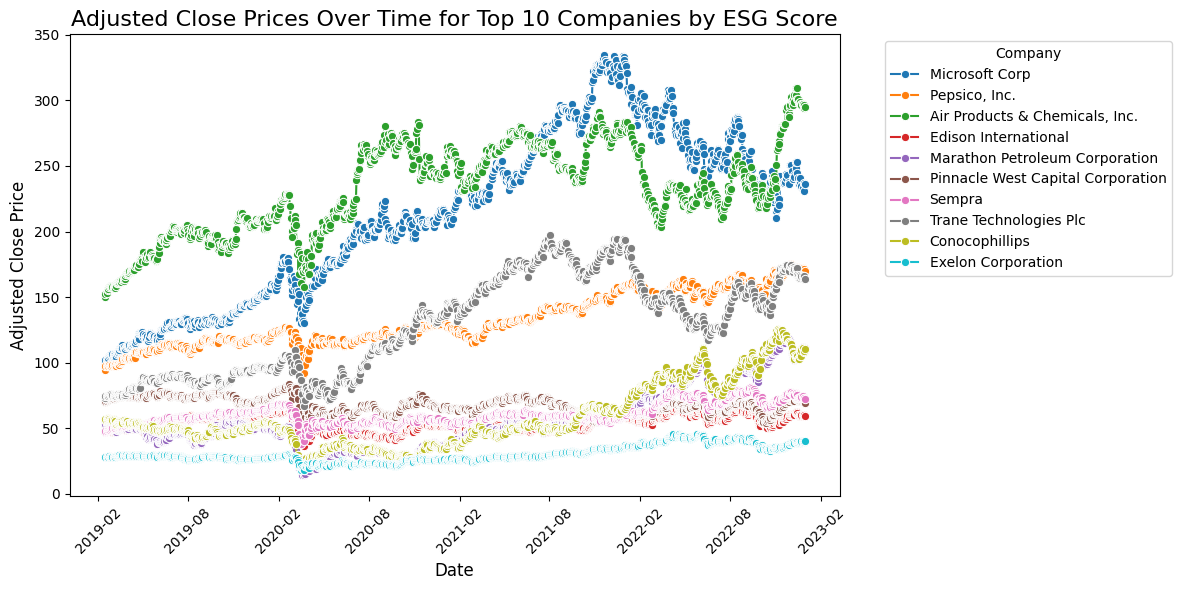

In [ ]:
#diễn biến giá cổ phiếu theo thời gian cho 10 công ty này
# Filter the original data for the top 10 companies
top_10_names = top_10_companies["Name"].tolist()
filtered_data = df[df["Name"].isin(top_10_names)]
filtered_data["Date"] = pd.to_datetime(filtered_data["Date"])
# Adjusted close prices over time
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=filtered_data,
    x="Date",
    y="adj_close",
    hue="Name",
    marker="o",
    palette="tab10"
)

# Format trục ngày như mẫu
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))   # dạng YYYY-MM
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))   # mỗi 6 tháng 1 tick

plt.title("Adjusted Close Prices Over Time for Top 10 Companies by ESG Score", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Adjusted Close Price", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

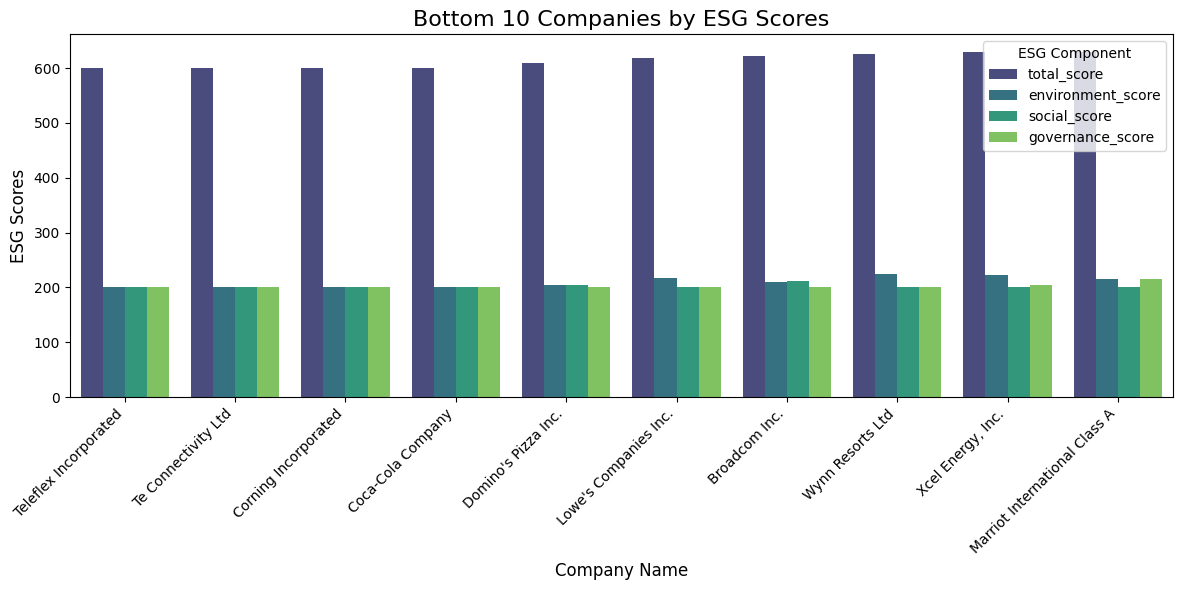

In [ ]:
bottom_10_companies = agg_data.sort_values(by="total_score", ascending=True).head(10)
bottom_10_companies_melted = bottom_10_companies.melt(
    id_vars="Name",
    value_vars=["total_score", "environment_score", "social_score", "governance_score"],
    var_name="ESG Component",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=bottom_10_companies_melted,
    x="Name",
    y="Score",
    hue="ESG Component",
    palette="viridis"
)

plt.title("Bottom 10 Companies by ESG Scores", fontsize=16)
plt.xlabel("Company Name", fontsize=12)
plt.ylabel("ESG Scores", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="ESG Component")
plt.tight_layout()

plt.show()

/tmp/ipython-input-50107846.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_bottom["Date"] = pd.to_datetime(filtered_data_bottom["Date"])


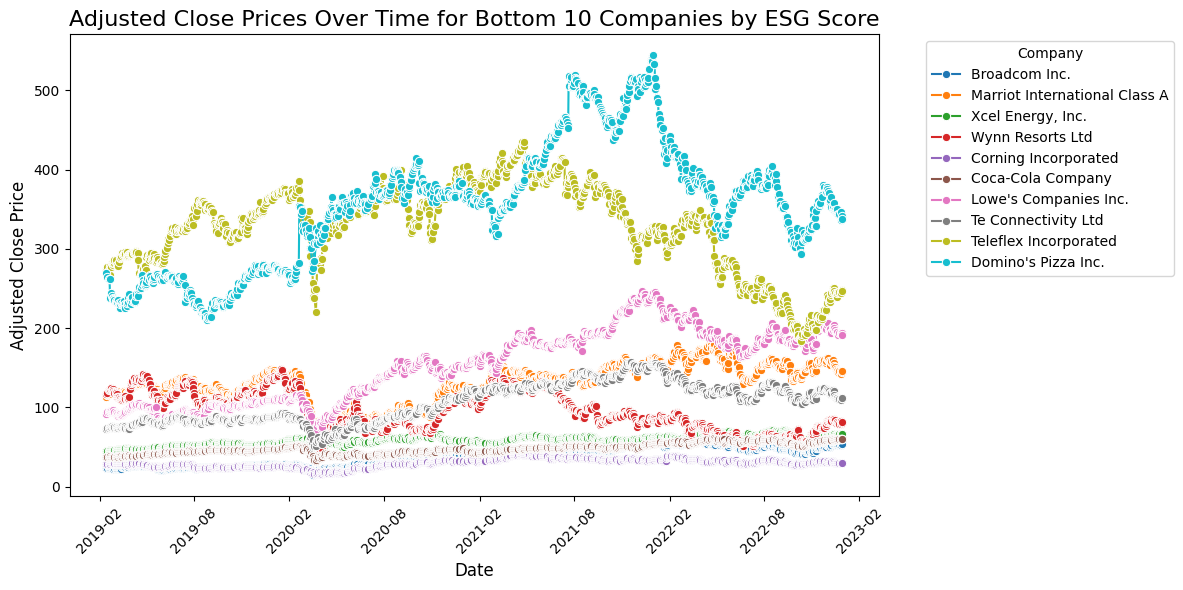

In [ ]:

# Sorting data by total_score and extracting the bottom 10 companies
bottom_10_companies = agg_data.sort_values(by="total_score", ascending=True).head(10)
bottom_10_names = bottom_10_companies["Name"].tolist()

filtered_data_bottom = df[df["Name"].isin(bottom_10_names)]
# Convert Date -> datetime (bắt buộc)
filtered_data_bottom["Date"] = pd.to_datetime(filtered_data_bottom["Date"])

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=filtered_data_bottom,
    x="Date",
    y="adj_close",
    hue="Name",
    marker="o",
    palette="tab10"
)

import matplotlib.dates as mdates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.title("Adjusted Close Prices Over Time for Bottom 10 Companies by ESG Score", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Adjusted Close Price", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Company", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()

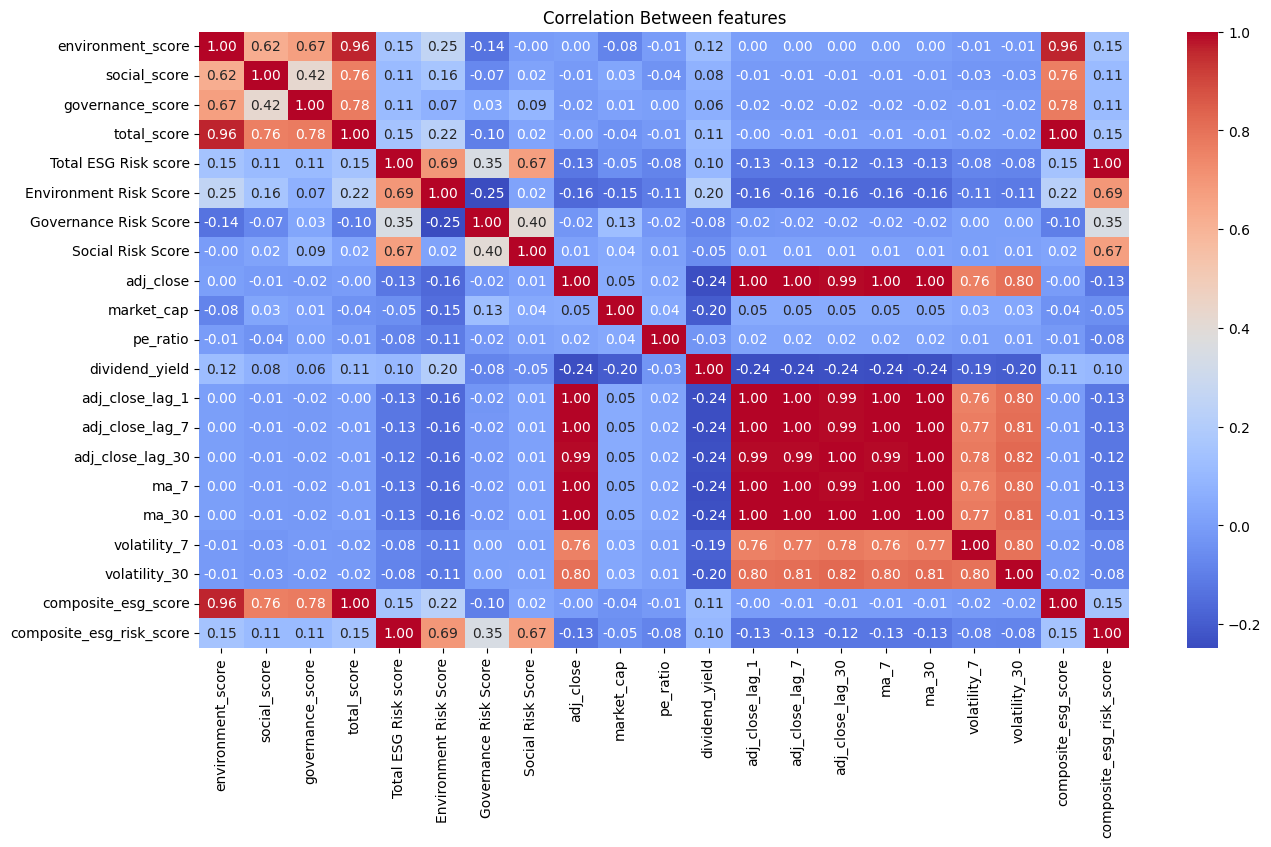


Các cặp biến có tương quan cao:
total_score           composite_esg_score         1.000000
Total ESG Risk score  composite_esg_risk_score    0.999961
adj_close             adj_close_lag_1             0.999632
adj_close_lag_1       ma_7                        0.999594
adj_close             ma_7                        0.999345
adj_close_lag_7       ma_7                        0.998999
                      ma_30                       0.998540
ma_7                  ma_30                       0.998207
adj_close_lag_1       adj_close_lag_7             0.997893
adj_close             adj_close_lag_7             0.997587
adj_close_lag_1       ma_30                       0.997378
adj_close             ma_30                       0.997123
adj_close_lag_30      ma_30                       0.996808
adj_close_lag_7       adj_close_lag_30            0.993023
adj_close_lag_30      ma_7                        0.992659
adj_close_lag_1       adj_close_lag_30            0.991874
adj_close             a

In [ ]:
# Select relevant columns for correlation
df_corr = df.drop(columns=['ticker', 'Name', 'Date'])
# Tính ma trận tương quan
correlation_matrix = df_corr.corr()
# Plot heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between features")
plt.show()
# Tìm các cặp biến có tương quan cao (>|0.8|)
high_corr = (
    correlation_matrix
    .abs()
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .loc[lambda x: x > 0.8]
    .sort_values(ascending=False)
)
print("\nCác cặp biến có tương quan cao:")
print(high_corr)
